# Zapomeňte na e-shopy: Python umí modelovat realitu – vektorová pole, tok a Stokesova věta

## Ukázka skalárního pole

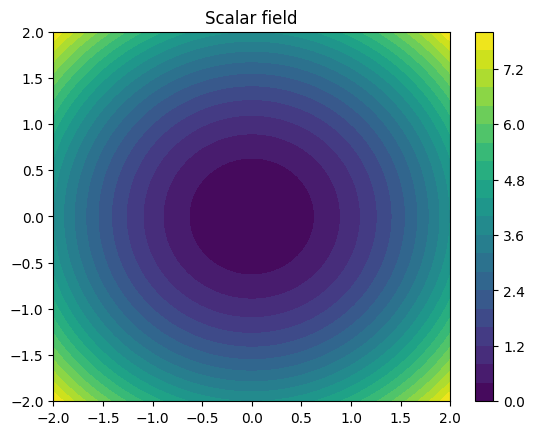

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-2,2,100)
y = np.linspace(-2,2,100)

X, Y = np.meshgrid(x,y)

Z = X**2 + Y**2

plt.contourf(X,Y,Z,20)
plt.colorbar()
plt.title("Scalar field")
plt.show()


## Ukázka vektorového pole

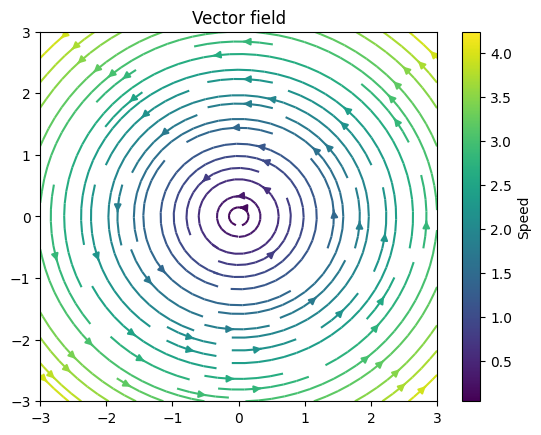

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-3,3,100)
y = np.linspace(-3,3,100)

X, Y = np.meshgrid(x,y)

U = -Y
V = X

speed = np.sqrt(U**2 + V**2)

plt.streamplot(X, Y, U, V, color=speed, cmap="viridis")
plt.colorbar(label="Speed")
plt.title("Vector field")
plt.show()

## Ukázka vizualizace gradientu

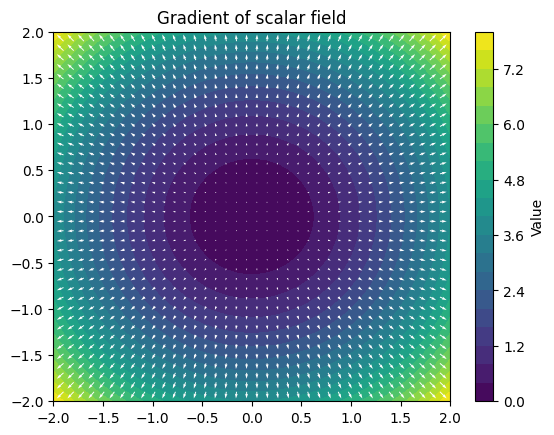

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# vytvoření souřadnic
x = np.linspace(-2, 2, 40)
y = np.linspace(-2, 2, 40)

X, Y = np.meshgrid(x, y)

# definice skalárního pole
Z = X**2 + Y**2

# výpočet gradientu
dZdy, dZdx = np.gradient(Z)

# vizualizace
plt.contourf(X, Y, Z, 20, cmap="viridis")
plt.colorbar(label="Value")

plt.quiver(X, Y, dZdx, dZdy, color="white")

plt.title("Gradient of scalar field")
plt.show()

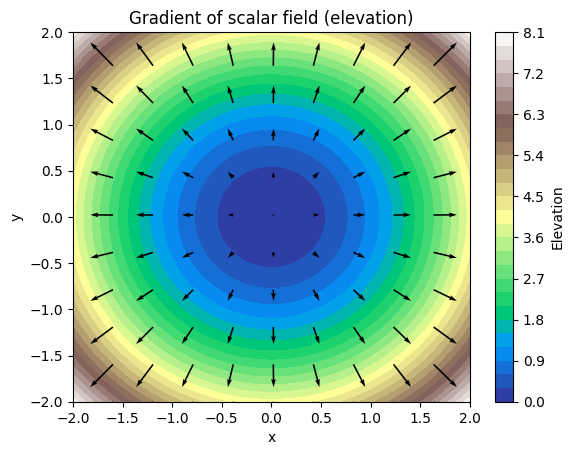

[[-2.         -1.95959596 -1.91919192 ...  1.91919192  1.95959596
   2.        ]
 [-2.         -1.95959596 -1.91919192 ...  1.91919192  1.95959596
   2.        ]
 [-2.         -1.95959596 -1.91919192 ...  1.91919192  1.95959596
   2.        ]
 ...
 [-2.         -1.95959596 -1.91919192 ...  1.91919192  1.95959596
   2.        ]
 [-2.         -1.95959596 -1.91919192 ...  1.91919192  1.95959596
   2.        ]
 [-2.         -1.95959596 -1.91919192 ...  1.91919192  1.95959596
   2.        ]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)

X, Y = np.meshgrid(x, y)

Z = X**2 + Y**2

dZdy, dZdx = np.gradient(Z)

plt.contourf(X, Y, Z, 30, cmap="terrain")
plt.colorbar(label="Elevation")

step = 10

plt.quiver(
    X[::step, ::step],
    Y[::step, ::step],
    dZdx[::step, ::step],
    dZdy[::step, ::step],
    color="black",
    scale=None,          # vypne automatické škálování
    width=0.004
)

plt.title("Gradient of scalar field (elevation)")
plt.xlabel("x")
plt.ylabel("y")

plt.show()

print(X)

## Ukázka divergence

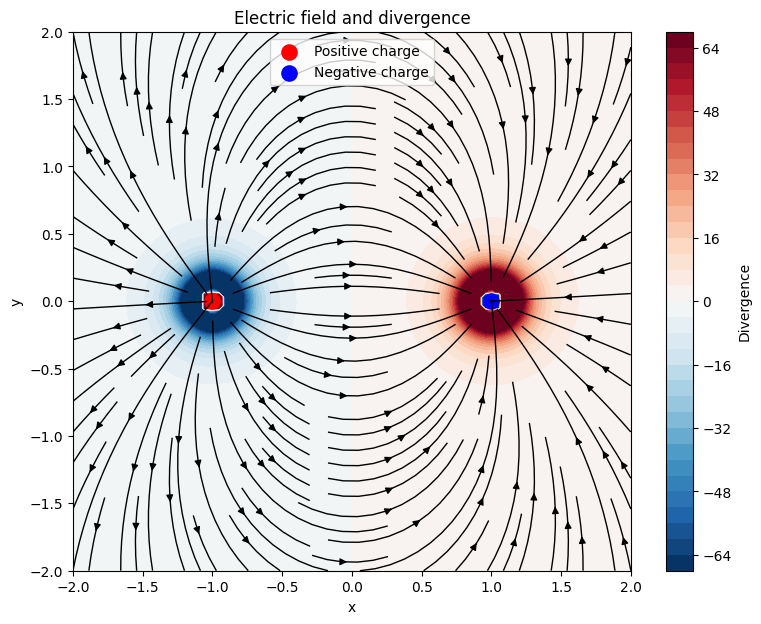

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# mřížka prostoru
x = np.linspace(-2, 2, 200)
y = np.linspace(-2, 2, 200)
X, Y = np.meshgrid(x, y)

# pozice nábojů
q1 = 1
q2 = -1
x1, y1 = -1, 0
x2, y2 = 1, 0

# vzdálenosti od nábojů
eps = 0.05
r1 = np.sqrt((X - x1)**2 + (Y - y1)**2 + eps**2)
r2 = np.sqrt((X - x2)**2 + (Y - y2)**2 + eps**2)

# elektrické pole
Ex = q1 * (X - x1) / r1**3 + q2 * (X - x2) / r2**3
Ey = q1 * (Y - y1) / r1**3 + q2 * (Y - y2) / r2**3

# divergence
dx = x[1] - x[0]
dy = y[1] - y[0]
dExdx = np.gradient(Ex, dx, axis=1)
dEydy = np.gradient(Ey, dy, axis=0)
div = dExdx + dEydy

# ořez extrémních hodnot pro lepší vizualizaci
limit = np.percentile(np.abs(div), 98)
div_clipped = np.clip(div, -limit, limit)

# barevná normalizace se středem v nule
norm = TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit)

# vykreslení
plt.figure(figsize=(9, 7))

plt.contourf(
    X, Y, div_clipped,
    levels=40,
    cmap="RdBu_r",
    norm=norm
)
plt.colorbar(label="Divergence")

plt.streamplot(X, Y, Ex, Ey, color="black", density=1.2, linewidth=1)

plt.scatter(x1, y1, color="red", s=120, label="Positive charge")
plt.scatter(x2, y2, color="blue", s=120, label="Negative charge")

plt.title("Electric field and divergence")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

## Ukázka rotace

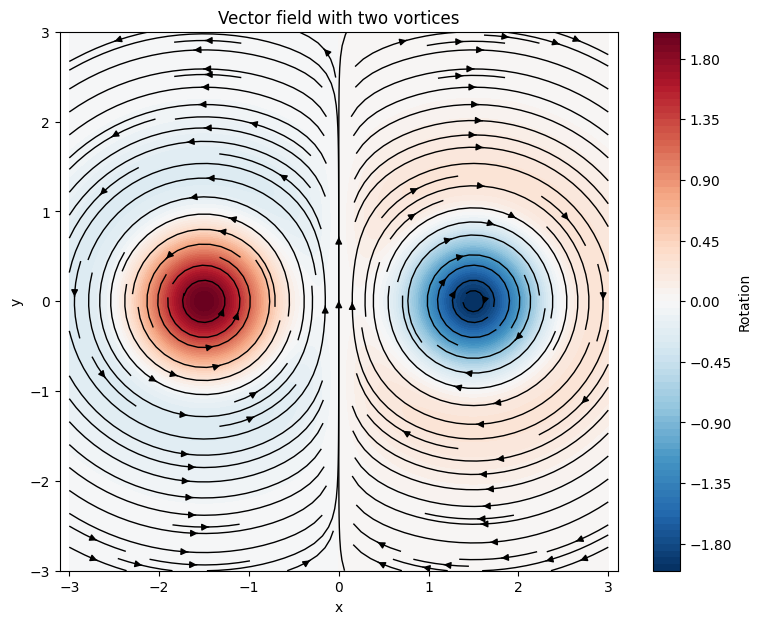

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# mřížka
x = np.linspace(-3, 3, 150)
y = np.linspace(-3, 3, 150)
X, Y = np.meshgrid(x, y)

# středy vírů
x1, y1 = -1.5, 0
x2, y2 = 1.5, 0

# vzdálenosti
r1 = (X-x1)**2 + (Y-y1)**2
r2 = (X-x2)**2 + (Y-y2)**2

# víry
U1 = -(Y-y1) * np.exp(-r1)
V1 =  (X-x1) * np.exp(-r1)

U2 =  (Y-y2) * np.exp(-r2)
V2 = -(X-x2) * np.exp(-r2)

# výsledné pole
U = U1 + U2
V = V1 + V2

# rotace
dx = x[1] - x[0]
dy = y[1] - y[0]

dVdx = np.gradient(V, dx, axis=1)
dUdy = np.gradient(U, dy, axis=0)

curl = dVdx - dUdy

# symetrická barevná škála
limit = np.max(np.abs(curl))
norm = TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit)

# graf
plt.figure(figsize=(9,7))

plt.contourf(X, Y, curl, levels=80, cmap="RdBu_r", norm=norm)
plt.colorbar(label="Rotation")

plt.streamplot(X, Y, U, V, color="black", density=1.6, linewidth=1)

plt.title("Vector field with two vortices")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")

plt.show()

## Tok vektorového pole ukázka

Flux: 12.650240005539821
Expected: 12.566370614359172


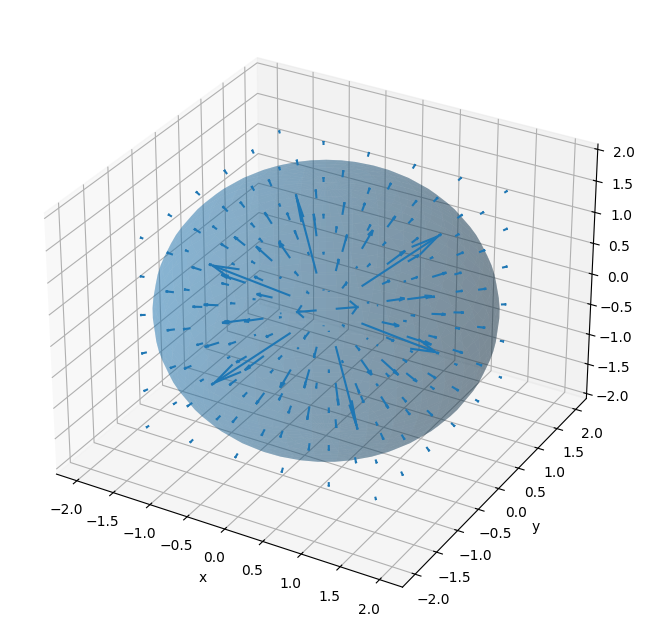

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- výpočet toku ----------

R = 2
n_theta = 150
n_phi = 150

theta = np.linspace(0, np.pi, n_theta)
phi = np.linspace(0, 2*np.pi, n_phi)

dtheta = theta[1] - theta[0]
dphi = phi[1] - phi[0]

flux = 0

for t in theta:
    for p in phi:

        x = R*np.sin(t)*np.cos(p)
        y = R*np.sin(t)*np.sin(p)
        z = R*np.cos(t)

        r = np.sqrt(x*x+y*y+z*z)

        # pole
        F = np.array([x,y,z]) / r**3

        # normála koule
        n = np.array([x,y,z]) / r

        # plošný element
        dS = R**2 * np.sin(t) * dtheta * dphi

        flux += np.dot(F, n) * dS

print("Flux:", flux)
print("Expected:", 4*np.pi)


# ---------- vizualizace ----------

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection='3d')

# koule
theta_v = np.linspace(0, np.pi, 40)
phi_v = np.linspace(0, 2*np.pi, 40)

theta_v, phi_v = np.meshgrid(theta_v, phi_v)

x = R*np.sin(theta_v)*np.cos(phi_v)
y = R*np.sin(theta_v)*np.sin(phi_v)
z = R*np.cos(theta_v)

ax.plot_surface(x, y, z, alpha=0.3)

# body pro pole
grid = np.linspace(-1.5,1.5,6)
X,Y,Z = np.meshgrid(grid,grid,grid)

r = np.sqrt(X**2 + Y**2 + Z**2)
r[r==0] = 1

Fx = X/r**3
Fy = Y/r**3
Fz = Z/r**3

ax.quiver(X,Y,Z,Fx,Fy,Fz,length=0.3)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.show()

## Ukázka Gaussovy věty

In [ ]:
import numpy as np

# ------------------------------------------------
# Definice vektorového pole
# ------------------------------------------------
# Radiální pole podobné elektrickému poli náboje

def field(x, y, z):
    r = np.sqrt(x*x + y*y + z*z)
    if r == 0:
        return np.array([0,0,0])
    return np.array([x, y, z]) / r**3


# ------------------------------------------------
# Tok přes kouli
# ------------------------------------------------

def flux_sphere(R, n=200):

    theta = np.linspace(0, np.pi, n)
    phi = np.linspace(0, 2*np.pi, n)

    dtheta = theta[1]-theta[0]
    dphi = phi[1]-phi[0]

    flux = 0

    for t in theta:
        for p in phi:

            x = R*np.sin(t)*np.cos(p)
            y = R*np.sin(t)*np.sin(p)
            z = R*np.cos(t)

            F = field(x,y,z)

            # normála koule
            n_vec = np.array([x,y,z]) / R

            # element plochy
            dS = R**2 * np.sin(t) * dtheta * dphi

            flux += np.dot(F, n_vec) * dS

    return flux


# ------------------------------------------------
# Tok přes krychli
# ------------------------------------------------

def flux_cube(a, n=80):

    flux = 0
    x = np.linspace(-a,a,n)
    y = np.linspace(-a,a,n)
    z = np.linspace(-a,a,n)

    dx = x[1]-x[0]
    dy = y[1]-y[0]
    dz = z[1]-z[0]

    # šest stěn krychle

    for X in x:
        for Y in y:

            # horní stěna
            F = field(X,Y,a)
            flux += np.dot(F,[0,0,1]) * dx*dy

            # dolní stěna
            F = field(X,Y,-a)
            flux += np.dot(F,[0,0,-1]) * dx*dy

    for X in x:
        for Z in z:

            # přední stěna
            F = field(X,a,Z)
            flux += np.dot(F,[0,1,0]) * dx*dz

            # zadní stěna
            F = field(X,-a,Z)
            flux += np.dot(F,[0,-1,0]) * dx*dz

    for Y in y:
        for Z in z:

            # pravá stěna
            F = field(a,Y,Z)
            flux += np.dot(F,[1,0,0]) * dy*dz

            # levá stěna
            F = field(-a,Y,Z)
            flux += np.dot(F,[-1,0,0]) * dy*dz

    return flux


# ------------------------------------------------
# Experiment
# ------------------------------------------------

print("Flux through spheres:")

for R in [0.5, 1, 2, 4]:
    print("R =", R, " -> ", flux_sphere(R))


print("\nFlux through cubes:")

for a in [0.5, 1, 2, 4]:
    print("a =", a, " -> ", flux_cube(a))


print("\nExpected value:", 4*np.pi)

Flux through spheres:
R = 0.5  ->  12.629255903790026
R = 1  ->  12.629255903790026
R = 2  ->  12.629255903790026
R = 4  ->  12.629255903790026

Flux through cubes:
a = 0.5  ->  12.741515254075336
a = 1  ->  12.741515254075365
a = 2  ->  12.741515254075336
a = 4  ->  12.741515254075365

Expected value: 12.566370614359172


## Ukázka cirkulace pole

Numerical circulation around the wire:
R = 0.5 -> 1.25663706e-06
R = 1.0 -> 1.25663706e-06
R = 2.0 -> 1.25663706e-06
R = 3.0 -> 1.25663706e-06

Expected value (mu0 * I): 1.25663706e-06


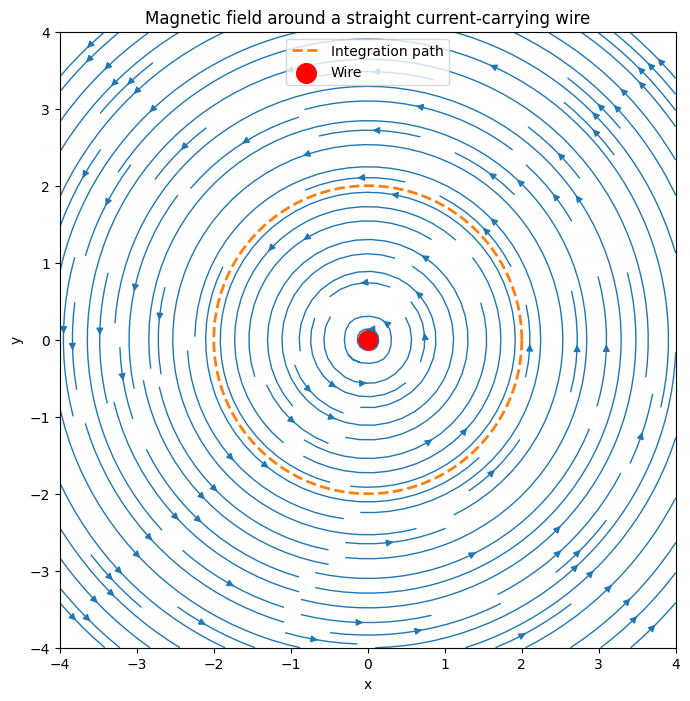

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Physical constants
mu0 = 4 * np.pi * 1e-7
I = 1.0

def magnetic_field(x, y):
    r2 = x**2 + y**2
    if r2 == 0:
        return np.array([0.0, 0.0])
    factor = mu0 * I / (2 * np.pi * r2)
    return np.array([-y, x]) * factor

def circulation_circle(R, n=2000):
    theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
    dtheta = 2 * np.pi / n

    circulation = 0.0

    for t in theta:
        x = R * np.cos(t)
        y = R * np.sin(t)

        Bx, By = magnetic_field(x, y)

        dx = -R * np.sin(t) * dtheta
        dy =  R * np.cos(t) * dtheta

        circulation += Bx * dx + By * dy

    return circulation

# Numerical experiment for different radii
radii = [0.5, 1.0, 2.0, 3.0]

print("Numerical circulation around the wire:")
for R in radii:
    value = circulation_circle(R)
    print(f"R = {R:.1f} -> {value:.8e}")

print(f"\nExpected value (mu0 * I): {mu0 * I:.8e}")

# Visualization
fig, ax = plt.subplots(figsize=(8, 8))

grid = np.linspace(-4, 4, 25)
X, Y = np.meshgrid(grid, grid)

U = np.zeros_like(X)
V = np.zeros_like(Y)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        bx, by = magnetic_field(X[i, j], Y[i, j])
        U[i, j] = bx
        V[i, j] = by

ax.streamplot(X, Y, U, V, density=1.4, linewidth=1)

# Draw the integration path
R_vis = 2.0
t = np.linspace(0, 2 * np.pi, 400)
xc = R_vis * np.cos(t)
yc = R_vis * np.sin(t)
ax.plot(xc, yc, linestyle="--", linewidth=2, label="Integration path")

# Mark the wire
ax.scatter(0, 0, color="r", s=200, label="Wire")

ax.set_title("Magnetic field around a straight current-carrying wire")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
ax.legend()
plt.show()

## Stokesova věta

Circle radius: 1.5
Circulation along boundary: 14.137167
Sum of curl over disk:      14.130816
Expected value:             14.137167


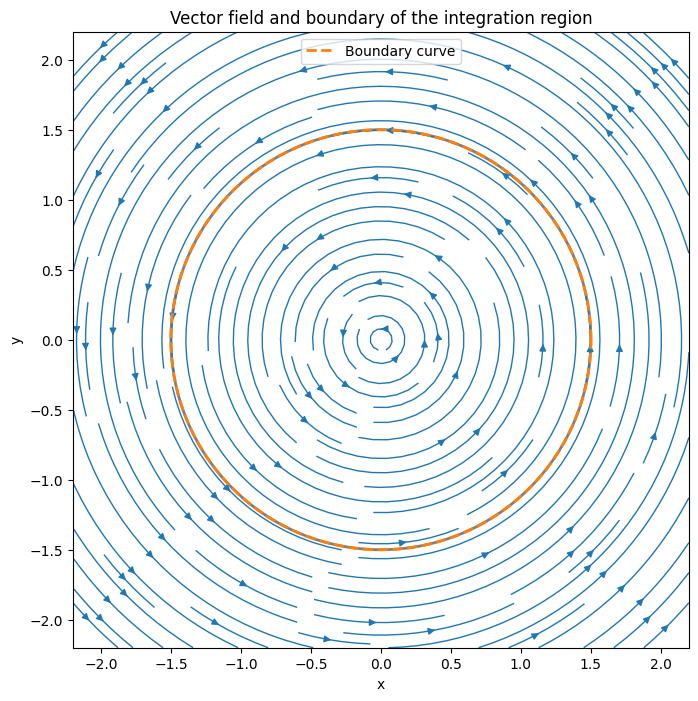

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def field(x, y):
    return np.array([-y, x])

def curl(x, y):
    return 2.0


def circulation_on_circle(R=1.0, n=2000):
    theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
    dtheta = 2 * np.pi / n

    total = 0.0

    for t in theta:
        x = R * np.cos(t)
        y = R * np.sin(t)

        Fx, Fy = field(x, y)

        dx = -R * np.sin(t) * dtheta
        dy =  R * np.cos(t) * dtheta

        total += Fx * dx + Fy * dy

    return total


def curl_flux_through_disk(R=1.0, n=400):
    x = np.linspace(-R, R, n)
    y = np.linspace(-R, R, n)
    dx = x[1] - x[0]
    dy = y[1] - y[0]

    total = 0.0

    for X in x:
        for Y in y:
            if X**2 + Y**2 <= R**2:
                total += curl(X, Y) * dx * dy

    return total


R = 1.5

circulation_value = circulation_on_circle(R=R)
curl_flux_value = curl_flux_through_disk(R=R)
expected_value = 2 * np.pi * R**2

print(f"Circle radius: {R}")
print(f"Circulation along boundary: {circulation_value:.6f}")
print(f"Sum of curl over disk:      {curl_flux_value:.6f}")
print(f"Expected value:             {expected_value:.6f}")


fig, ax = plt.subplots(figsize=(8, 8))

grid = np.linspace(-2.2, 2.2, 25)
X, Y = np.meshgrid(grid, grid)

U = -Y
V = X

ax.streamplot(X, Y, U, V, density=1.4, linewidth=1)

t = np.linspace(0, 2 * np.pi, 400)
xc = R * np.cos(t)
yc = R * np.sin(t)
ax.plot(xc, yc, "--", linewidth=2, label="Boundary curve")

disk = plt.Circle((0, 0), R, fill=False, linewidth=2, alpha=0.5)
ax.add_patch(disk)

ax.set_title("Vector field and boundary of the integration region")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
ax.legend()
plt.show()